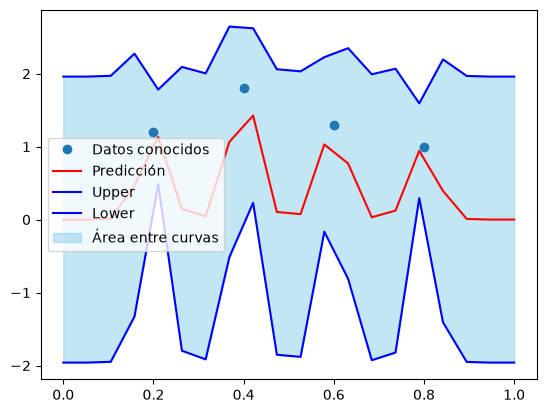

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# 1. Conjunto de puntos conocidos (datos de entrenamiento)
#En este caso tenemos un arreglo vertical de puntos. Cada punto en este caso es un valor de x.
X = np.array([0.2, 0.4, 0.6, 0.8]).reshape(-1,1)   # puntos conocidos
y = np.array([1.2, 1.8, 1.3, 1.0])     # valores de la función en cada uno de los puntos.

# 2. Definir kernel (covarianza)
kernel = RBF(length_scale=0.5)

# 3. Ajustar el modelo GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp.fit(X, y)

# 4. Punto candidato
x_new=np.linspace(0,1,20).reshape(-1,1)

# 5. Predicción (interpolación bayesiana)
mu, sigma = gp.predict(x_new, return_std=True)

upp=mu+1.96*sigma
low=mu-1.96*sigma
plt.plot(X, y, 'o', label='Datos conocidos')
plt.plot(x_new, mu, 'r-', label='Predicción')
plt.plot(x_new, upp, 'b-', label='Upper')
plt.plot(x_new, low, 'b-', label='Lower')
plt.fill_between(x_new.reshape(1,-1)[0], low, upp, color="skyblue", alpha=0.5, label="Área entre curvas")
plt.legend()

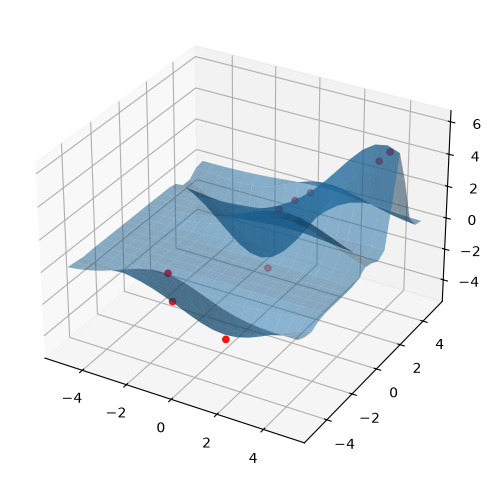

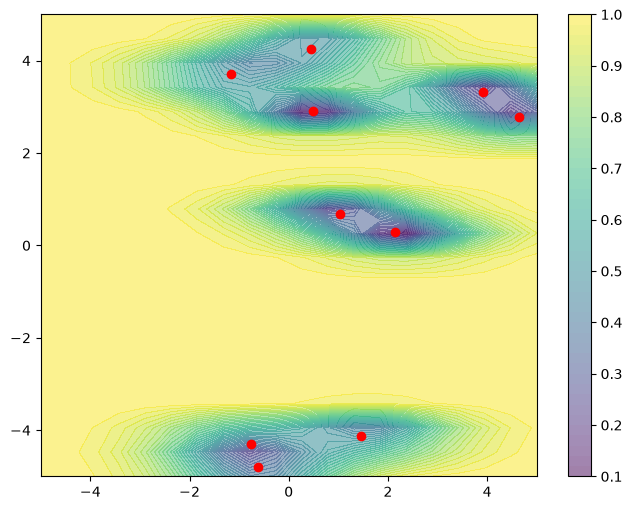

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

#Definimos una función en dos dimensiones
def true_function(x, y):
    return np.sin(x) + np.cos(y) + 0.5 * x * y

#Definimos un vector inicial de puntos en x y y
np.random.seed(0)
num_samples = 10
x_data = np.random.uniform(-5, 5, num_samples)
y_data = np.random.uniform(-5, 5, num_samples)

#Combinamos los valores para que cada fila sea un par de valores de x, y y cada fila corresponde a un conjunto de valores, que se mapearan a un valor de Z
X_train = np.vstack((x_data, y_data)).T

#Se crea una función con valores de ruido aleatorio.
noise_level = 0.5
y_train = true_function(x_data, y_data) + np.random.normal(0, noise_level, num_samples)

#Se define el kernel para el modelo
# A common choice is the Radial Basis Function (RBF) kernel, potentially with a WhiteKernel for noise
kernel = RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2))# + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))

# 3. Instantiate and fit the GaussianProcessRegressor
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, n_restarts_optimizer=10, random_state=0)
gpr.fit(X_train, y_train)

# 4. Make predictions on a new grid of data
# Create a grid for prediction
x_predict = np.linspace(-5, 5, 20)
y_predict = np.linspace(-5, 5, 20)
X_predict_grid = np.array(np.meshgrid(x_predict, y_predict)).T.reshape(-1, 2)
Xm, Ym=np.meshgrid(x_predict, y_predict)

# Predict mean and standard deviation
y_pred, sigma = gpr.predict(X_predict_grid, return_std=True)

# Reshape predictions for plotting (optional, for visualization)
y_pred_reshaped = y_pred.reshape(len(x_predict), len(y_predict)).T
sigma_reshaped = sigma.reshape(len(x_predict), len(y_predict)).T

from mpl_toolkits.mplot3d import Axes3D  # Necesario para proyecciones 3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train[:, 0], X_train[:, 1], y_train, color='red', label='Datos de entrenamiento')
ax.plot_surface(Xm, Ym, y_pred_reshaped, alpha=0.5)

fig = plt.figure(figsize=(8, 6))
plt.plot(X_train[:, 0], X_train[:, 1],'ro')
plt.contourf(Xm, Ym, sigma_reshaped, 50, cmap='viridis', alpha=0.5)
plt.colorbar()


Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0009
Function value obtained: -0.0591
Current minimum: -0.0591
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.0002
Function value obtained: -0.2951
Current minimum: -0.2951
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.0002
Function value obtained: 0.7782
Current minimum: -0.2951
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.0002
Function value obtained: 0.8972
Current minimum: -0.2951
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.0002
Function value obtained: 0.2425
Current minimum: -0.2951
Iteration No: 6 started. Eva

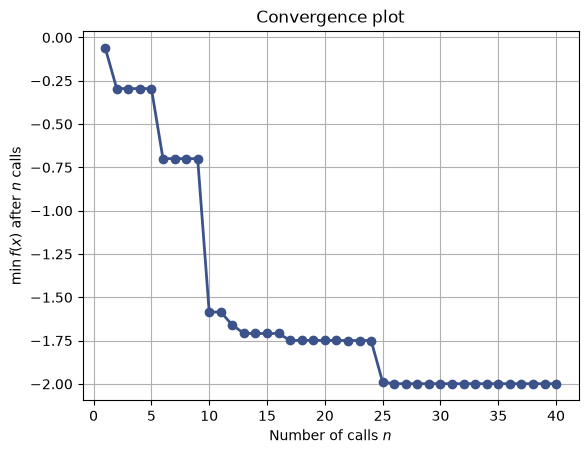

In [3]:
import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
# ---------------------------
# Definir espacio de búsqueda (3D)
# ---------------------------
space = [
    Real(0.0, 1.0, name="x"),
    Real(0.0, 1.0, name="y"),
    Real(0.0, 1.0, name="z")
]
# ---------------------------
# Función objetivo
# ---------------------------
@use_named_args(space)
def objective(x, y, z):
    return np.sin(5*x) + np.cos(5*y) + (z - 0.5)**2

res = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=40,             # número de evaluaciones
    n_initial_points=6,     # puntos iniciales aleatorios
    acq_func="EI",          # Expected Improvement
    random_state=42,
    n_points=2000,           # número de puntos en la grilla
    verbose=True
)

print("Mejor punto encontrado:")
print(f"x = {res.x[0]:.4f}, y = {res.x[1]:.4f}, z = {res.x[2]:.4f}")
print(f"f(x,y,z) = {res.fun:.6f}")

# ---------------------------
# Gráfica de convergencia
# ---------------------------
import matplotlib.pyplot as plt
plot_convergence(res)
plt.show()